**Objective:**
This notebook transforms exploratory findings into actionable business insights and strategic recommendations to support data-driven decision-making.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/superstore_features.csv",
    parse_dates=["order_date", "ship_date"]
)

## Executive Summary

In [4]:
print("Total Sales:", round(df["sales"].sum(), 2))
print("Total Profit:", round(df["profit"].sum(), 2))
print("Total Orders:", df["order_id"].nunique())
print("Total Customers:", df["customer_id"].nunique())
print("Average Profit Margin:", round(df["profit_margin"].mean(), 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793
Average Profit Margin: 12.03 %



The analysis examined over 9,900 retail transactions to evaluate sales performance, profitability, customer behavior, and operational efficiency.

Major findings include:

• Technology generated the highest revenue.

• The West region contributed the largest share of sales.

• Consumer customers accounted for most purchases.

• High discounts frequently reduced profitability.

• Several sub-categories generated consistent losses.

• Standard Class was the most frequently used shipping method.

The following sections discuss these findings and their business implications.

## Revenue Strategy
### Business Question

Which areas should the company prioritize to maximize revenue growth?

In [31]:
revenue_summary = (
    df.groupby("category")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Average_Profit_Margin=("profit_margin", "mean"),
          Total_Orders=("order_id", "count")
      )
      .sort_values("Total_Sales", ascending=False)
)

revenue_summary.style.format({
    "Total_Sales": "${:,.2f}",
    "Total_Profit": "${:,.2f}",
    "Average_Profit_Margin": "{:.2f}%",
    "Total_Orders": "{:,.0f}"
})

,Total_Sales,Total_Profit,Average_Profit_Margin,Total_Orders
category,,,,
Technology,"$836,154.03","$145,454.95",15.61%,"1,847"
Furniture,"$741,999.80","$18,451.27",3.88%,"2,121"
Office Supplies,"$719,047.03","$122,490.80",13.80%,"6,026"


### Insight

Technology generated **$836,154** in total sales and **$145,454** in total profit, making it the company's highest-performing category.

Furniture generated substantial revenue but a noticeably lower profit margin, suggesting higher operational costs or heavier discounting.

### Recommendation

Increase investment in Technology products while reviewing pricing and cost structure for Furniture.

## Product Performance
### Business Question

Which products should management promote or review?

In [14]:
top_products = (
    df.groupby("sub_category")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
      .sort_values("Total_Profit", ascending=False)
      .head(10)
)

top_products

,Total_Sales,Total_Profit
sub_category,,
Copiers,149528.030,55617.8249
Phones,330007.054,44515.7306
Accessories,167380.318,41936.6357
Paper,78479.206,34053.5693
Binders,203412.733,30221.7633
Chairs,328449.103,26590.1663
Storage,223843.608,21278.8264
Appliances,107532.161,18138.0054
Furnishings,91705.164,13059.1436


### Insight

Phones and Copiers consistently generate strong profits.

Tables and Bookcases produce frequent losses despite generating significant revenue.

### Recommendation

Increase promotion of high-margin products while reviewing pricing and discount policies for underperforming sub-categories.

## Customer Strategy
### Business Question

Which customer segment creates the greatest business value?

In [35]:
customer_summary = (
    df.groupby("segment")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Average_Order_Value=("sales", "mean")
      )
      .sort_values("Total_Sales", ascending=False)
)

customer_summary.style.format({
    "Total_Sales": "${:,.2f}",
    "Total_Profit": "${:,.2f}",
    "Average_Order_Value": "${:,.2f}"
})

,Total_Sales,Total_Profit,Average_Order_Value
segment,,,
Consumer,"$1,161,401.34","$134,119.21",$223.73
Corporate,"$706,146.37","$91,979.13",$233.82
Home Office,"$429,653.15","$60,298.68",$240.97


### Insight

The Consumer segment contributes the highest revenue due to its large customer base.

Corporate customers exhibit strong profitability and may represent opportunities for long-term partnerships.

### Recommendation

Maintain marketing efforts toward Consumer customers while developing loyalty programs targeting Corporate clients.

## Regional Strategy
### Business Question

Which regions deserve additional investment?

In [32]:
regional_summary = (
    df.groupby("region")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Average_Profit_Margin=("profit_margin", "mean"),
          Total_Orders=("order_id", "count")
      )
      .sort_values("Total_Sales", ascending=False)
)

regional_summary.style.format({
    "Total_Sales": "${:,.2f}",
    "Total_Profit": "${:,.2f}",
    "Average_Profit_Margin": "{:.2f}%",
    "Total_Orders": "{:,.0f}"
})

,Total_Sales,Total_Profit,Average_Profit_Margin,Total_Orders
region,,,,
West,"$725,457.82","$108,418.45",21.95%,"3,203"
East,"$678,781.24","$91,522.78",16.72%,"2,848"
Central,"$501,239.89","$39,706.36",-10.41%,"2,323"
South,"$391,721.91","$46,749.43",16.35%,"1,620"


<Axes: title={'center': 'Total Sales and Profit by Region'}, xlabel='region'>

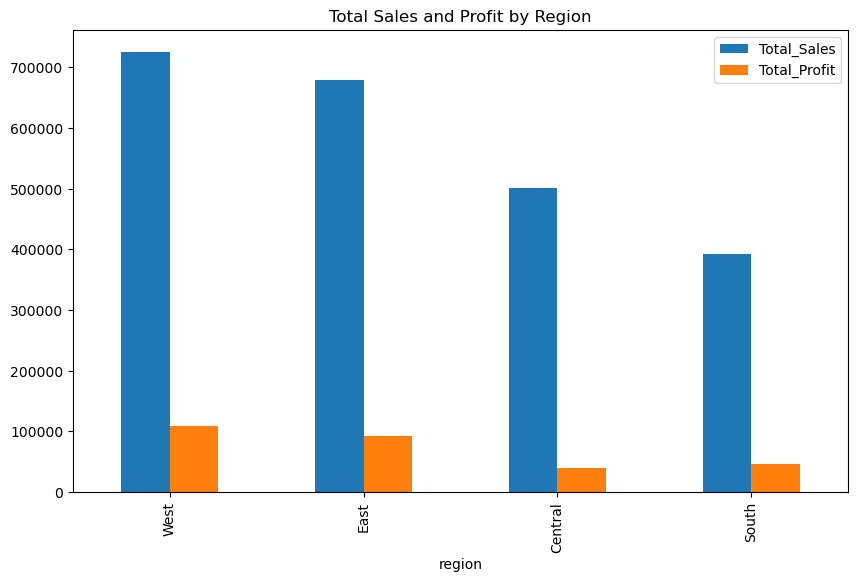

In [39]:
regional_summary.plot(
    kind="bar",
    y=["Total_Sales", "Total_Profit"],
    figsize=(10, 6),
    title="Total Sales and Profit by Region"
)

### Insight

The West region consistently outperforms other regions in both revenue and profit.

The South region generates comparatively lower sales and profit.

### Recommendation

Investigate demand limitations in the South and evaluate targeted promotional campaigns to improve regional performance.

## Discount Strategy
 
### Business Question:

Is the current discount strategy sustainable?

In [36]:
discount_summary = (
    df.groupby("discount_level")
      .agg(
          Average_Profit=("profit", "mean"),
          Average_Sales=("sales", "mean"),
          Order_Count=("order_id", "count")
      )
)

discount_summary.style.format({
    "Average_Profit": "${:,.2f}",
    "Average_Sales": "${:,.2f}",
    "Order_Count": "{:,.0f}"
})

,Average_Profit,Average_Sales,Order_Count
discount_level,,,
High,$-89.44,$75.03,856
Low,$26.50,$222.59,"3,803"
Medium,$-109.53,$555.94,537
No Discount,$66.90,$226.74,"4,798"


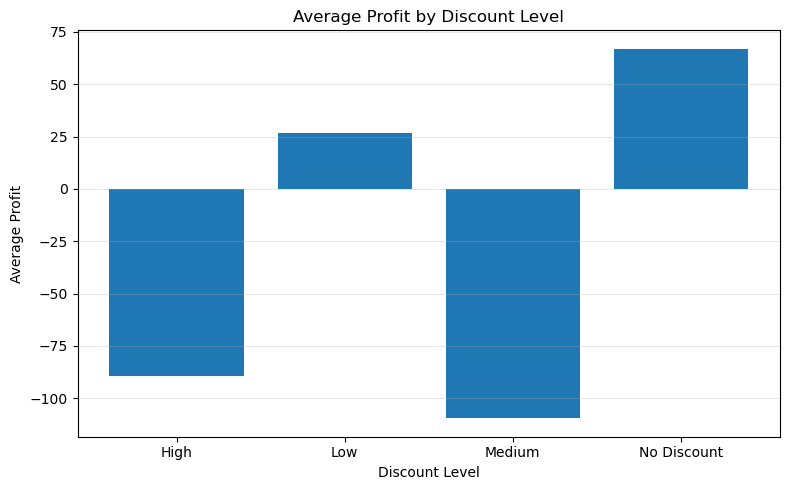

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    discount_summary.index.astype(str),
    discount_summary["Average_Profit"]
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount Level")
plt.ylabel("Average Profit")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

Profit declines noticeably as discount levels increase.

Several heavily discounted orders result in financial losses.

### Recommendation

Limit high discounts to strategic campaigns and focus promotional efforts on products with healthy profit margins.

## Shipping Performance

## Business Question:

Can delivery performance be improved?

In [40]:
shipping_summary = (
    df.groupby("ship_mode")
      .agg(
          Average_Shipping_Days=("shipping_days", "mean"),
          Total_Orders=("order_id", "count"),
          Total_Sales=("sales", "sum")
      )
      .sort_values("Total_Orders", ascending=False)
)

shipping_summary.style.format({
    "Average_Shipping_Days": "{:.2f}",
    "Total_Orders": "{:,.0f}",
    "Total_Sales": "${:,.2f}"
})

,Average_Shipping_Days,Total_Orders,Total_Sales
ship_mode,,,
Standard Class,5.01,"5,968","$1,358,215.74"
Second Class,3.24,"1,945","$459,193.57"
First Class,2.18,"1,538","$351,428.42"
Same Day,0.04,543,"$128,363.12"


### Insight

Standard Class has the longest delivery time but is also the most frequently selected shipping method.

Premium shipping options reduce delivery time but are used less frequently.

### Recommendation

Evaluate whether faster shipping options could improve customer satisfaction for high-value orders.

## Weekly Sales Pattern

### Business Question

Which day generates the highest sales?

In [41]:
weekly_summary = (
    df.groupby("day_of_week")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Orders=("order_id", "count")
      )
)

weekly_summary.style.format({
    "Total_Sales": "${:,.2f}",
    "Total_Profit": "${:,.2f}",
    "Orders": "{:,.0f}"
})

,Total_Sales,Total_Profit,Orders
day_of_week,,,
Friday,"$427,692.26","$46,520.82","1,818"
Monday,"$428,937.82","$51,511.11","1,871"
Saturday,"$357,984.68","$41,277.62","1,655"
Sunday,"$385,353.85","$57,129.51","1,710"
Thursday,"$321,965.78","$39,683.75","1,463"
Tuesday,"$287,209.50","$35,570.33","1,106"
Wednesday,"$88,056.98","$14,703.87",371


### Insight

Sales peak on certain weekdays, indicating opportunities for scheduling promotions and inventory replenishment.

### Recommendation

Launch marketing campaigns before peak sales days to maximize customer engagement.

## KPI Summary Table

In [43]:
kpi_summary.style.format({
    "Value": "{:,.2f}"
})

,KPI,Value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Total Orders,"5,009.00"
3,Total Customers,793.00
4,Average Profit Margin (%),12.03


# Key Takeaways

| Business Area | Key Finding | Business Impact |
|--------------|-------------|-----------------|
| Revenue | Technology generated the highest revenue among all product categories. | Continue investing in Technology products to sustain revenue growth. |
| Profitability | Some high-sales products generated low or negative profits due to heavy discounting. | Revenue growth should be balanced with profitability rather than sales alone. |
| Customer Segments | The Consumer segment contributed the largest share of total sales. | Consumer customers remain the primary target market for marketing campaigns. |
| Regional Performance | The West region consistently outperformed other regions in both sales and profit. | Successful sales strategies from the West can be adapted to lower-performing regions. |
| Product Performance | Certain sub-categories generated consistent losses despite reasonable sales. | Review pricing, discounts, and product mix for underperforming products. |
| Discounts | Higher discount levels were associated with lower average profits. | Excessive discounting negatively affects profitability and should be carefully managed. |
| Shipping | Standard Class was the most commonly used shipping method. | Evaluate opportunities to improve delivery efficiency without increasing logistics costs. |
| Weekly Trends | Sales varied across different days of the week. | Promotional campaigns can be scheduled around peak sales days to maximize revenue. |

## Final Business Recommendations
###  Strategic Recommendations

1. Increase investment in Technology products due to their strong revenue and profitability.

2. Review pricing and discount strategies for loss-making sub-categories such as Tables.

3. Reduce excessive discounting, as higher discounts frequently reduce profit.

4. Expand successful sales strategies from the West region to lower-performing regions.

5. Strengthen relationships with Corporate customers through loyalty programs.

6. Monitor shipping performance and evaluate premium shipping options for high-value orders.

## Conclusion

This analysis demonstrates that revenue growth alone does not guarantee profitability.

Future business improvements should focus on optimizing product mix, refining discount strategies, and targeting profitable customer segments.

The insights generated in this notebook will also support the SQL analysis and Power BI dashboard developed in the next stages of the project.

## Next Steps

The cleaned and feature-engineered dataset will now be imported into PostgreSQL for relational analysis. SQL will be used to answer additional business questions, optimize queries, and prepare aggregated data for Excel and Power BI dashboards.